# Weighted ECM clustering
## Toys dataset - 2 clusters, 2 dimensions


In [13]:
## Importing
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

import numpy as np
import matplotlib.pyplot as plt
from evclust.utils import plotting, display_results_fuzzy_partition, display_results_evidential, ev_plot_2D
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import math

from evclust.wecm_new_barycenter_2 import wecm as wecm2
from evclust.gwecm import gwecm

In [14]:
# Generating data set
# Number of points in each cluster
num_points = 200

# Number of dimensions for each point
num_dimensions = 6

# Mean and covariance matrices for each cluster
identity = np.eye(6)
cov_matrix1 = np.array([5, 8, 3, 7, 9, 4]).reshape((6, 1)) * identity
cov_matrix2 = np.array([5, 2, 10, 3, 1, 8]).reshape((6, 1)) * identity

cluster_params = [
    {"mean": [3, 1, 1, 1, 1, 1], "covariance": cov_matrix1, "label": 0},
    {"mean": [3, 12, 5, 5, 5, 12], "covariance": cov_matrix2, "label": 1},
]

# Generate data for each cluster
# data = np.concatenate([np.random.multivariate_normal(params["mean"], params["covariance"], num_points) for params in cluster_params])
dataset = np.concatenate(
    [np.column_stack((np.random.multivariate_normal(params["mean"], params["covariance"], num_points),
                      np.full((num_points, 1), params["label"]))) for params in cluster_params])

Instances 400 - Features 6 - Class 2
          0         1         2         3         4         5
0  0.284161  2.925043 -1.544330  2.403582  3.885639  3.613877
1  6.158403  2.981439  1.414375 -0.612750  4.002370  5.089474
2  2.289664 -3.031106  0.760837 -0.918285 -6.447820 -1.956233
3  2.614417  3.209525 -0.605743  1.940057  2.153136 -0.246628
4  2.383119 -1.233200 -0.527209 -2.026742  4.573104  0.316552


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


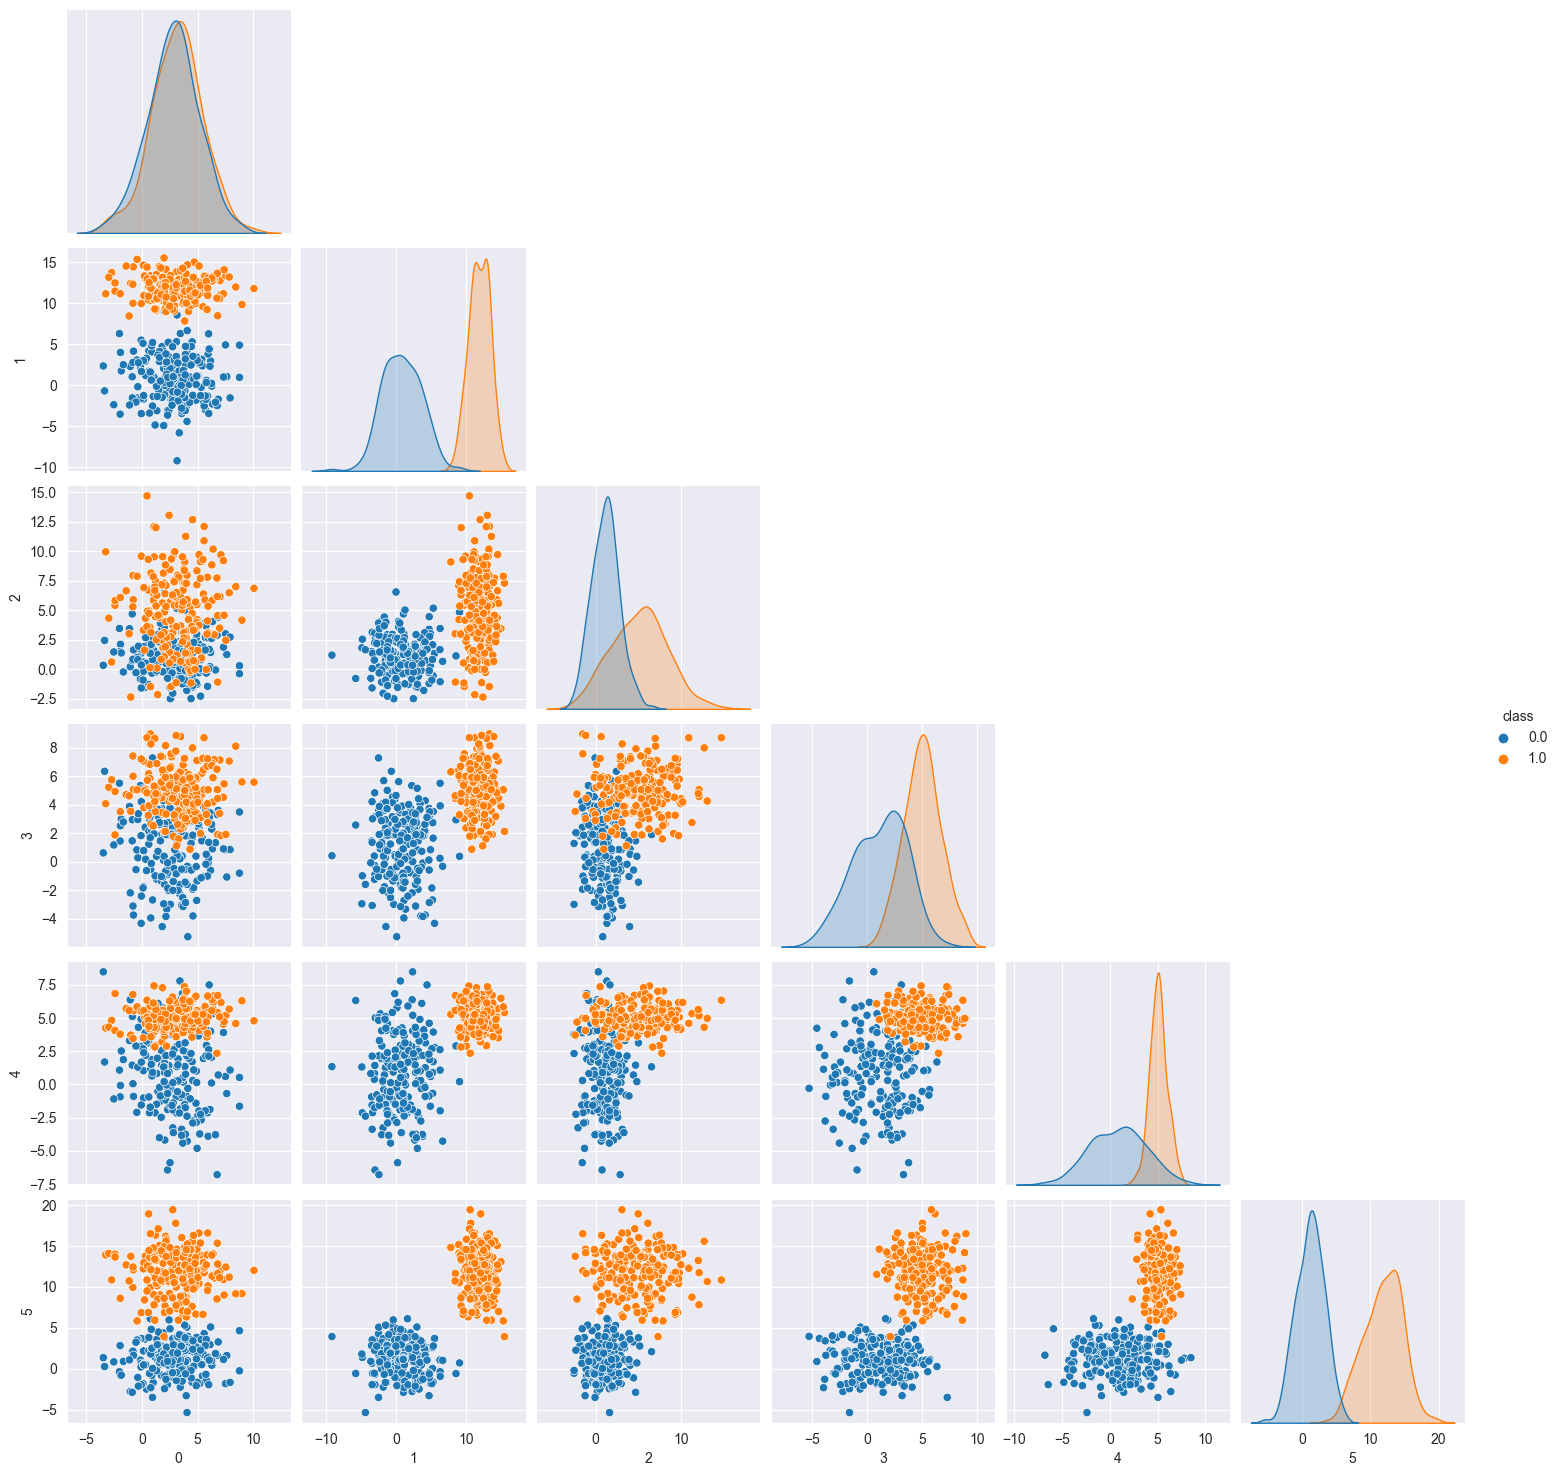

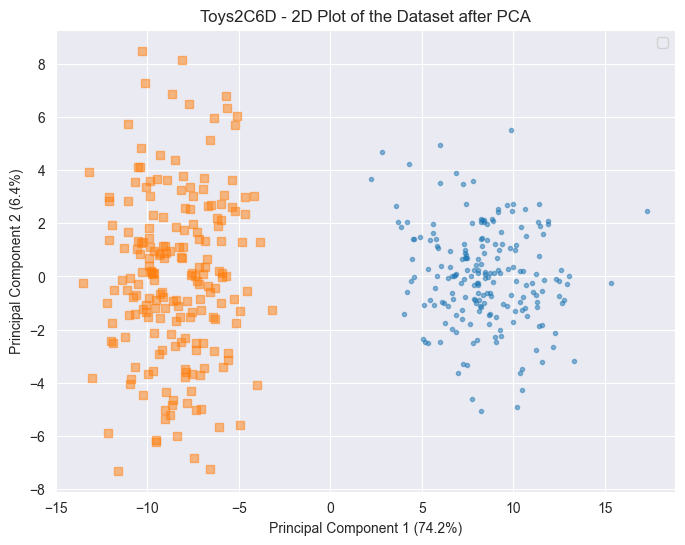

In [15]:

# df_wt_label = pd.read_csv('../../src/evclust/datasets/2dDataset.csv')
# dataset = df_wt_label.values
X = pd.DataFrame(dataset[:, :-1])
y = pd.DataFrame(dataset[:, -1])
c = 2

label_column_nm = y.columns[0]
labels_encoder = LabelEncoder()
numeric_labels = labels_encoder.fit_transform(y[label_column_nm])

# markers = ['^', 's']
plotting(X, y, "Toys2C6D", matrix_plot=True, markers=None)

# Normalization
scaler = MinMaxScaler((0,1))
X = pd.DataFrame(scaler.fit_transform(X))

## WECM2

In [16]:
# %%capture
wecm2_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(3):
    model = wecm2(x=X, c=c, beta=2, alpha=1, delta=delta, init="None", epsilon=1e-3, stopping_factor="center")
    wecm2_models = np.append(wecm2_models, model)

wecm2_models = sorted(wecm2_models, key=lambda model: model['crit'])

Initial weights: 
 [[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
 [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
 [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]]
Initial prototypes: 
 [[0.62903785 1.05551729 0.65183786 0.92456719 0.73823234 0.76431965]
 [0.55857161 0.38216976 0.14367502 0.19029907 0.23429081 0.39267986]]
[1, 1.1087545290887246]
[2, 0.6519934875730833]
[3, 0.6328351727192154]
[4, 0.6197685472430808]
[5, 0.6177614086505977]
[6, 0.6155493437052938]
Initial weights: 
 [[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
 [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
 [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]]
Initial prototypes: 
 [[0.53783018 0.39070898 0.34389767 0.24273797 0.48536593 0.30855755]
 [0.56338899 0.35764848 0.28328621 0.05110867 0.24977945 0.03806624]]
[1, 1.4714036678423819]
[2, 1.1436747964455556]
[3, 1.2040025651115376]
Initial 

J values: [0.6155493437052938, 0.6428306740502417, 1.2040025651115376]
ARI values: [1.0, 1.0, 0.4817261003940892]
NS values: [0.7461598509780594, 0.7813648107075528, 1.0009625012908234]
NMI values: [1.0, 1.0, 0.38395895698793514]


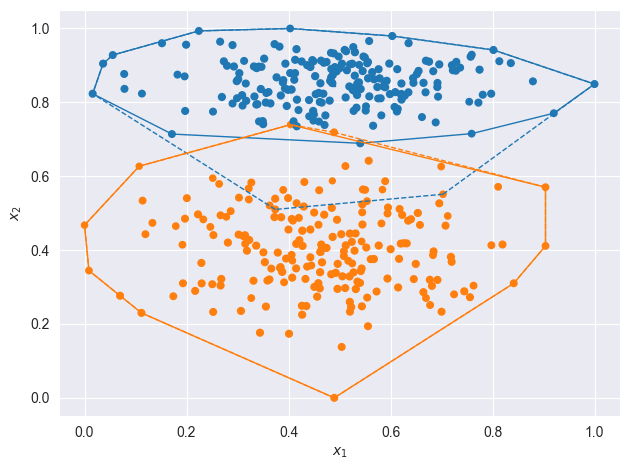

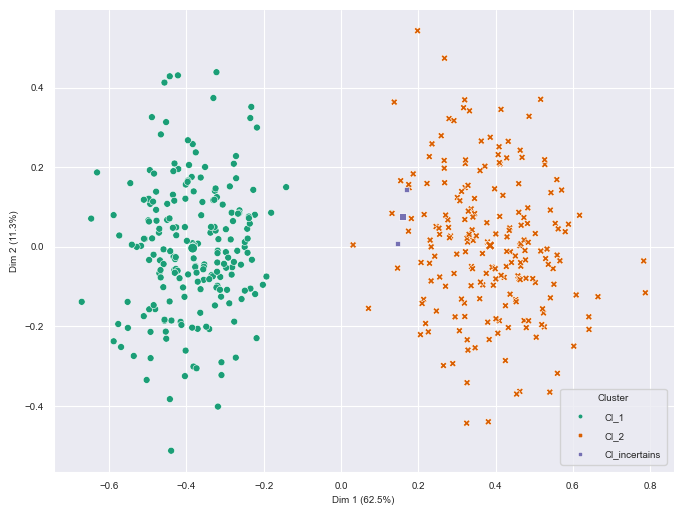

Covariance: 
 [5. 8. 3. 7. 9. 4.] 
 [ 5.  2. 10.  3.  1.  8.]
Weights: 
 [[0.05505282 0.28912422 0.04449376 0.10854094 0.39202209 0.11076617]
 [0.08452663 0.18400831 0.27782856 0.07749816 0.06626062 0.30987772]
 [0.18495963 0.06403162 0.3084822  0.17069197 0.10522488 0.16660971]]


In [17]:
display_results_evidential(X, wecm2_models, numeric_labels)

print(f"Covariance: \n {np.diag(cov_matrix1)} \n {np.diag(cov_matrix2)}")
print(f"Weights: \n {wecm2_models[0]['W']}")

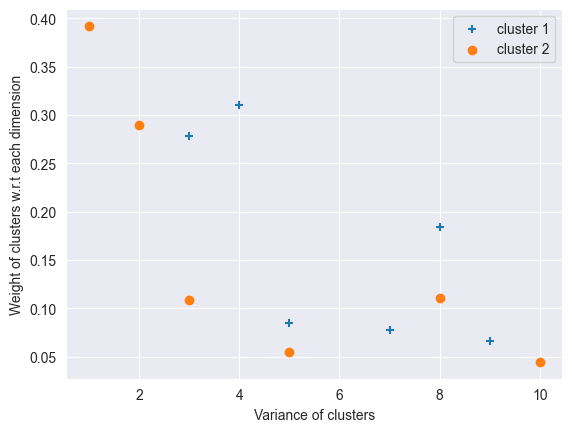

In [20]:
W = wecm2_models[0]['W']
W_COV_1 = pd.DataFrame({'y': W[1, :], 'x': np.diag(cov_matrix1)})
W_COV_1.sort_values('x', inplace=True)
W_COV_2 = pd.DataFrame({'y': W[0, :], 'x': np.diag(cov_matrix2)})
W_COV_2.sort_values('x', inplace=True)

plt.clf()
plt.scatter(W_COV_1['x'], W_COV_1['y'], label = "cluster 1", marker = '+')
plt.scatter(W_COV_2['x'], W_COV_2['y'], label = "cluster 2", marker = 'o')
plt.xlabel("Variance of clusters")
plt.ylabel("Weight of clusters w.r.t each dimension")
plt.legend()
# plt.figure(figsize=(8, 6))
plt.show()